In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv(r"C:\Users\sivap\OneDrive\Desktop\project_2\Salary Data.csv")

In [8]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Level,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,Medium,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,Fresher,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,Expert,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,Medium,60000.0
4,52.0,Male,Master's,Director,20.0,Expert,200000.0


In [9]:
df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Level,Salary
369,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,Medium,85000.0
370,43.0,Male,Master's,Director of Operations,19.0,Expert,170000.0
371,29.0,Female,Bachelor's,Junior Project Manager,2.0,Fresher,40000.0
372,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,Medium,90000.0
373,44.0,Female,PhD,Senior Business Analyst,15.0,Expert,150000.0


In [10]:
df.shape

(374, 7)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Level                374 non-null    str    
 6   Salary               373 non-null    float64
dtypes: float64(3), str(4)
memory usage: 20.6 KB


In [12]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [13]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Level', 'Salary'],
      dtype='str')

In [14]:
df.isnull().sum()

Age                    1
Gender                 1
Education Level        1
Job Title              1
Years of Experience    1
Level                  0
Salary                 1
dtype: int64

In [15]:
df = df.dropna()

In [16]:
df.duplicated().sum()

np.int64(49)

In [17]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Level,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,Medium,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,Fresher,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,Expert,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,Medium,60000.0
4,52.0,Male,Master's,Director,20.0,Expert,200000.0


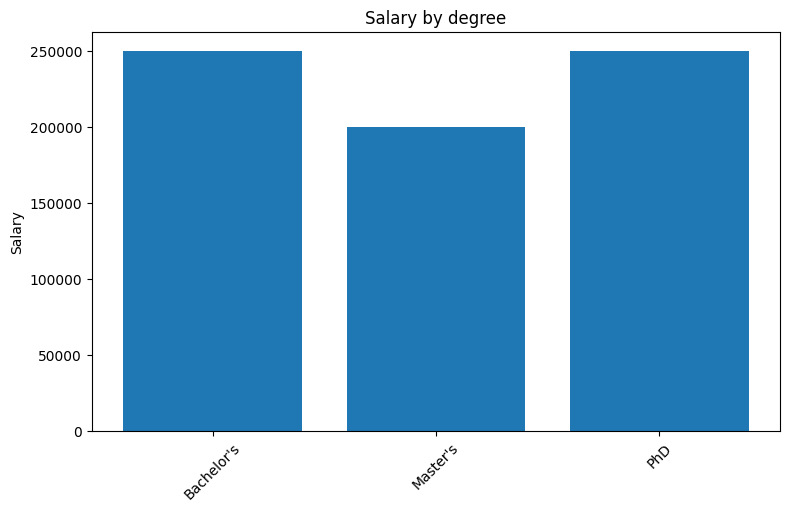

In [18]:
# Visualize the relationship between education level and salary
plt.figure(figsize=(8,5))
plt.bar(df['Education Level'], df['Salary'])
plt.ylabel('Salary')
plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Salary by degree')
plt.show()

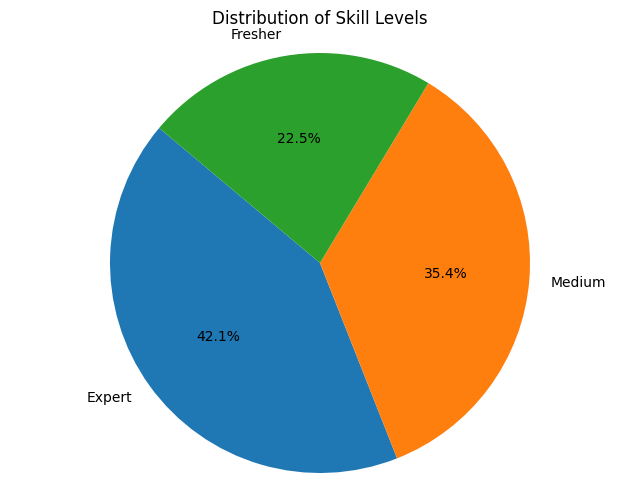

In [19]:
# Visualize the relationship between skill level and salary by using pie chart
skill_counts = df['Level'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(skill_counts, labels=skill_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Skill Levels')
plt.axis('equal')
plt.show()

In [20]:
# Defining x and y values
x = df.drop(['Age','Salary', 'Gender','Education Level','Level', 'Job Title'], axis=1)
y = df['Salary']

In [21]:
x

,Years of Experience
0,5.0
1,3.0
2,15.0
3,7.0
4,20.0
...,...
369,8.0
370,19.0
371,2.0
372,7.0


In [22]:
# Splitting the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
x_test

,Years of Experience
328,21.0
33,10.0
15,16.0
315,6.0
57,17.0
...,...
94,7.0
196,11.0
312,4.0
293,14.0


In [24]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Level,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,Medium,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,Fresher,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,Expert,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,Medium,60000.0
4,52.0,Male,Master's,Director,20.0,Expert,200000.0
...,...,...,...,...,...,...,...
369,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,Medium,85000.0
370,43.0,Male,Master's,Director of Operations,19.0,Expert,170000.0
371,29.0,Female,Bachelor's,Junior Project Manager,2.0,Fresher,40000.0
372,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,Medium,90000.0


In [25]:
print(x_train.dtypes)

Years of Experience    float64
dtype: object


In [26]:
print(y_train.dtypes)

float64


In [27]:
# Define & create slr
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
# Create a sample employee using same structure as training data

sample = x_train.iloc[[0]].copy()

# Change experience value
sample['Years of Experience'] = 5

# Predict salary
predicted_salary = lr.predict(sample)

print("Predicted Salary:", round(predicted_salary[0],2))

Predicted Salary: 65634.03


In [28]:
# Make prediction
y_pred = lr.predict(x_test).round(2)
y_pred 

array([174795.47,  99746.98, 140682.52,  72456.62, 147505.11, 154327.7 ,
       181618.06,  99746.98,  51988.85,  92924.39, 120214.75, 174795.47,
        45166.26,  92924.39, 127037.34,  51988.85,  65634.03,  41754.96,
        79279.21,  86101.8 ,  99746.98,  92924.39, 140682.52,  65634.03,
        72456.62,  58811.44, 154327.7 ,  45166.26, 120214.75, 161150.29,
        51988.85, 127037.34,  51988.85, 133859.93,  99746.98,  34932.37,
       174795.47,  45166.26, 154327.7 ,  58811.44,  45166.26,  92924.39,
       202085.83, 161150.29,  45166.26, 140682.52, 106569.57,  45166.26,
        45166.26,  45166.26, 161150.29,  86101.8 , 120214.75, 113392.16,
        92924.39, 113392.16, 202085.83,  79279.21, 174795.47,  72456.62,
       113392.16, 133859.93, 167972.88,  65634.03,  51988.85,  45166.26,
        51988.85,  99746.98,  45166.26,  31521.08,  79279.21, 106569.57,
        58811.44, 127037.34,  86101.8 ])

In [ ]:
# y_test vs y_pred
df1 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).round(2)
df1

,Actual,Predicted
328,180000.0,174795.47
33,65000.0,99746.98
15,125000.0,140682.52
315,80000.0,72456.62
57,140000.0,147505.11
...,...,...
94,75000.0,79279.21
196,90000.0,106569.57
312,60000.0,58811.44
293,140000.0,127037.34


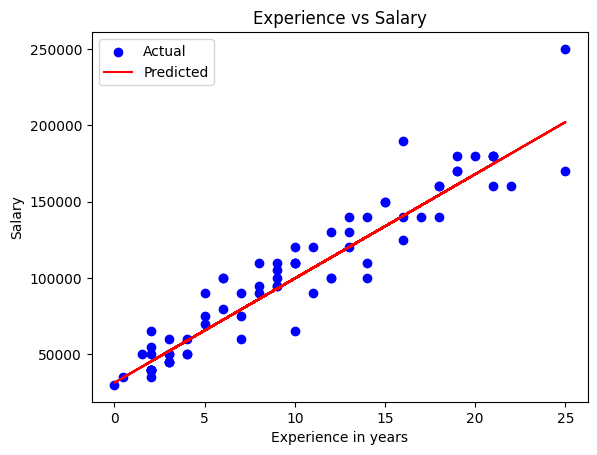

In [ ]:
# visualize the regression line
# Plot the actual data points
plt.scatter(x_test['Years of Experience'], y_test, color='blue', label='Actual')
plt.plot(x_test['Years of Experience'], y_pred, color='red', label='Predicted')

plt.xlabel('Experience in years')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.legend()
plt.show()

In [ ]:
# Evaluate the model
# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred).__round__(2)
print(f"Mean Absolute Error: {mae}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred).__round__(2)
print(f"Mean Squared Error: {mse}")

# Calculate R-squared score
r2 = r2_score(y_test, y_pred).__round__(2)
print(f"R-squared score: {r2}")

Mean Absolute Error: 12094.17
Mean Squared Error: 241834882.79
R-squared score: 0.9
